In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../../Data.csv")
data = data.drop(columns=["VD", "VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

In [ ]:
import seaborn as sns

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        for target in TARGET:
            sns.lineplot(x=df.index, y=df[target], ax=ax2, marker="o", label=target, linestyle="dashed", linewidth=2, color="red")
            ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Exibindo o gráfico
    plt.show()

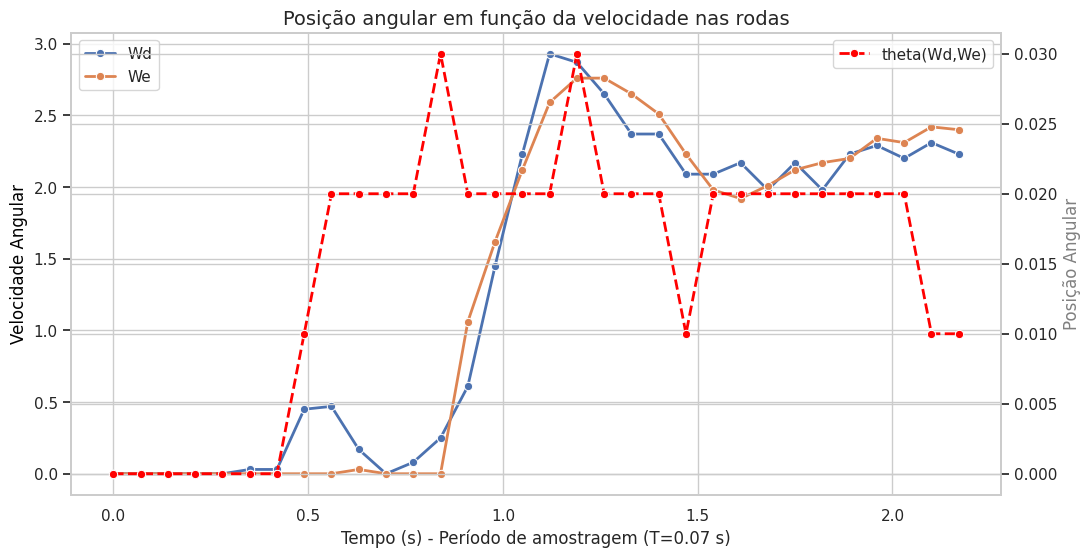

In [5]:
PlotTimeSeries(data.head(32))

In [6]:
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

def get_XY(data, time_steps, units, output_dim):
    total_samples = (len(data) - time_steps) // time_steps

    X = []
    Y = []
    
    for i in range(total_samples):
        start_idx = i * time_steps
        end_idx = start_idx + time_steps

        X_seq = data.iloc[start_idx:end_idx][PREDICTORS].values  # shape: (time_steps, features)
        Y_target = data.iloc[end_idx][TARGET]  # escalar

        X.append(X_seq)
        Y.append(Y_target)

    X = np.array(X)  # shape: (batch, time_steps, features)
    Y =  Y = np.array(Y).reshape(-1, 1).repeat(output_dim, axis=1)  # shape (batch, output_dim)
    h0 = np.full((X.shape[0], units), fill_value=Y[0]) # shape (batch, units)

    print(f"Shape X (batch, time_steps, features): {X.shape}")
    print(f"Shape Y (batch, output_dim): {Y.shape}")
    print(f"Shape h0 (batch, units): {h0.shape}")
    
    return X, Y, h0

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from sklearn.preprocessing import StandardScaler
from keras import layers, models, regularizers
from keras.callbacks import EarlyStopping


class EvalRNN:
    
    def __init__(self, Dataset, units, time_steps, output_dim, epochs):
        self.units = units
        self.output_dim = output_dim
        self.epochs = epochs
    
        train_data, test_data = train_test_split(Dataset, test_size=0.25, shuffle=False)
        train_data, val_data = train_test_split(train_data, test_size=0.15, shuffle=False)
                
        self.train_samples_x, self.train_samples_y, self.h0_train = get_XY(train_data, time_steps, units, output_dim)       
        self.val_samples_x, self.val_samples_y, self.h0_val = get_XY(val_data, time_steps, units, output_dim)
        self.test_samples_x, self.test_samples_y, self.h0_test = get_XY(test_data, time_steps, units, output_dim)

        self.batchSize = self.train_samples_x.shape[0]
        self.timeSteps = self.train_samples_x.shape[1]
        self.features = self.train_samples_x.shape[2]

    def BuildModel(self):
        inputs = layers.Input((self.timeSteps, self.features))
        initial_state = layers.Input((self.units,))

        rnn = layers.SimpleRNN(
            self.units,
            kernel_regularizer=regularizers.l2(0.01),
        )
        hidden = rnn(inputs, initial_state=initial_state)
        output = layers.Dense(self.output_dim,
                               kernel_regularizer=regularizers.l2(0.01))(hidden)
        model = models.Model([inputs] + [initial_state], output)
        return(model)
    
    def CompileModel(self, model):
        model.compile(loss="mse", optimizer="adam")
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.fit(
            [self.train_samples_x, self.h0_train],
            self.train_samples_y,
            epochs=self.epochs,
            validation_data=([self.val_samples_x, self.h0_val], self.val_samples_y),
            callbacks=[early_stop],
            verbose=False,
            shuffle=False   
        )
    
    def ComputeMetrics(self, model):
        self.train_pred = model.predict([self.train_samples_x, self.h0_train])
        self.val_pred = model.predict([self.val_samples_x, self.h0_val])        
        self.test_pred = model.predict([self.test_samples_x, self.h0_test])


        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
                    
                    'r2_val': r2_score(self.val_samples_y, self.val_pred),
                    'mse_val': mean_squared_error(self.val_samples_y, self.val_pred),
                    'mape_val': mean_absolute_percentage_error(self.val_samples_y, self.val_pred),
                    'rmse_val': root_mean_squared_error(self.val_samples_y, self.val_pred),
            })

    def PlotOut(self):
        sns.set_theme(style="whitegrid")

        fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharey=False)

        datasets = [
            ('Treinamento', self.train_samples_y, self.train_pred),
            ('Validação', self.val_samples_y, self.val_pred),
            ('Teste', self.test_samples_y, self.test_pred)
        ]

        times = [
            np.arange(len(self.train_samples_y)),
            np.arange(len(self.val_samples_y)),
            np.arange(len(self.test_samples_y))
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            # Garante que são vetores 1D
            y_true = np.ravel(y_true)
            y_pred = np.ravel(y_pred)

            sns.lineplot(x=times[i], y=y_true, ax=axs[i], marker="o", label="Amostras Reais", linewidth=2)
            sns.lineplot(x=times[i], y=y_pred, ax=axs[i], marker="o", label="Valores preditos", linewidth=2)

            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Tempo')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação temporal: Predição (curva) vs Amostras Reais (pontos)')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    def Evaluate(self):
        model = self.BuildModel()
        self.CompileModel(model)
        metrics = self.ComputeMetrics(model)
        
        print(metrics)
        df = pd.DataFrame([metrics])
        df.to_excel('metrics.xlsx', sheet_name='Results', index=False)

        self.PlotOut()  

In [12]:
Vsg = EvalRNN(Dataset=data,
              units=10,
              time_steps=2,
              output_dim=1,
              epochs=100)        

Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 10)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 10)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 10)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
{'r2_training': -1.8641047546390745, 'mse_training': 0.4077221045492772, 'mape_training': 47488083001443.555, 'rmse_training': 0.6385312087512067, 'r2_test': -18.73648831760961, 'mse_test': 0.42995777426328974, 'mape_test': 0.9850750590974334, 'rmse_test': 0.6557116548173364, 'r2_val': -113.24189279678468, 'mse_val': 0.020353303886816047, 'mape_val': 90228828493147.03, 'rmse_val': 0.1426650058241896}


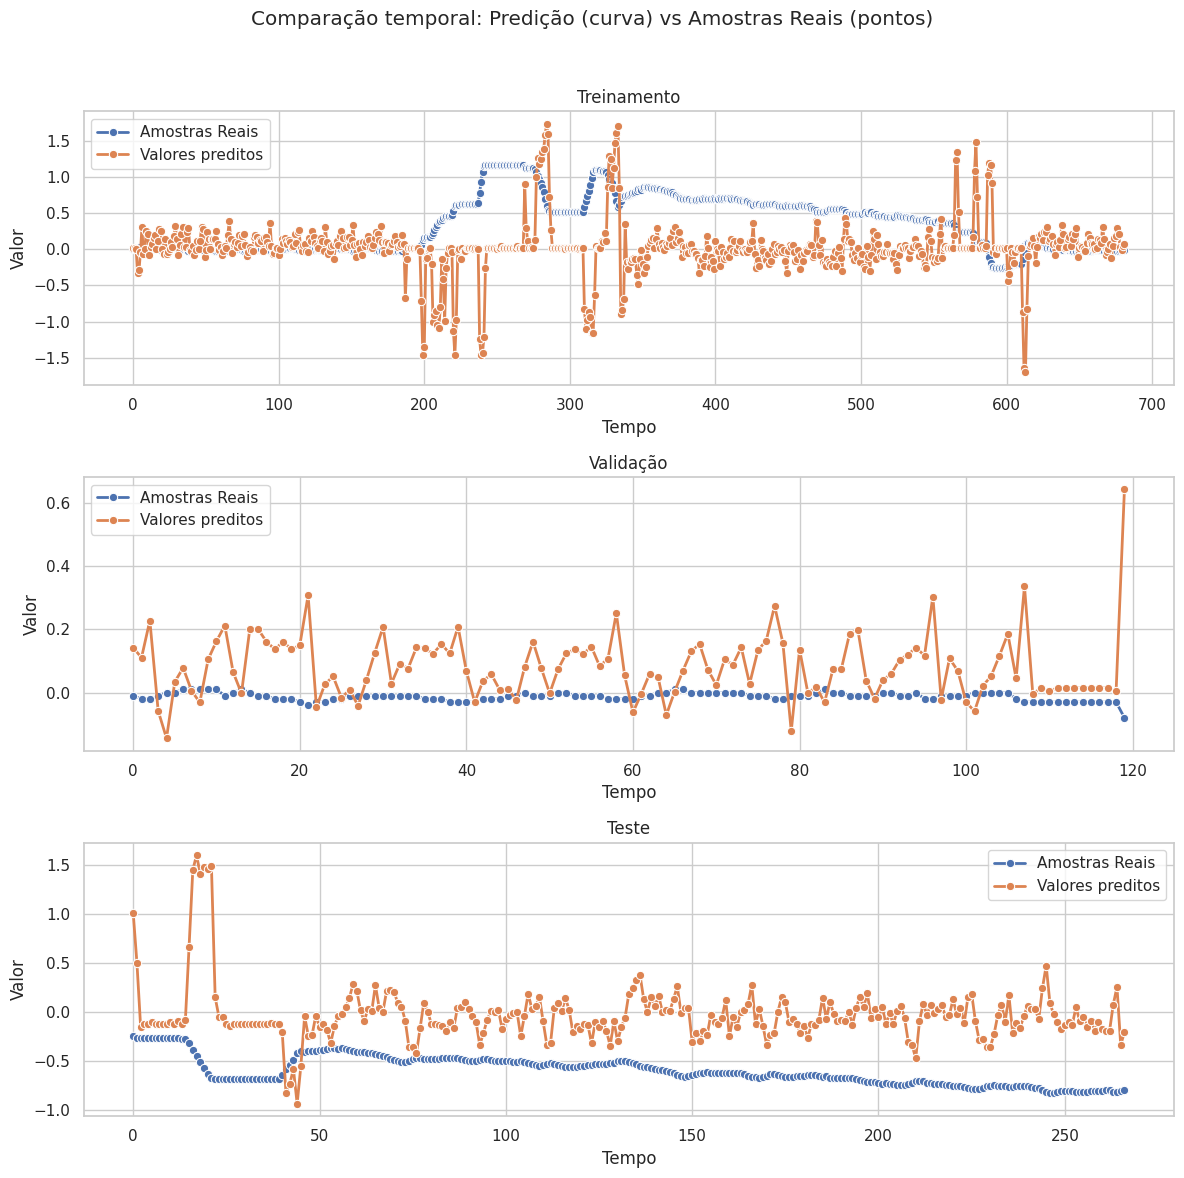

In [13]:
Vsg.Evaluate() 